In [1]:
import numpy as np
from cdasws import CdasWs

start_time = "2025-09-27T00:00:00"
end_time = "2025-10-7T00:00:00"
out_name = './plots/storm_sept30-rev1.png'
#target_time = "1997-10-10T17:04:00"

In [2]:
dataset = 'OMNI_HRO_1MIN'
cdas = CdasWs()
var_names = cdas.get_variable_names(dataset)
var_names

['IMF',
 'PLS',
 'IMF_PTS',
 'PLS_PTS',
 'percent_interp',
 'Timeshift',
 'RMS_Timeshift',
 'RMS_phase',
 'Time_btwn_obs',
 'F',
 'BX_GSE',
 'BY_GSE',
 'BZ_GSE',
 'BY_GSM',
 'BZ_GSM',
 'RMS_SD_B',
 'RMS_SD_fld_vec',
 'flow_speed',
 'Vx',
 'Vy',
 'Vz',
 'proton_density',
 'T',
 'Pressure',
 'E',
 'Beta',
 'Mach_num',
 'Mgs_mach_num',
 'x',
 'y',
 'z',
 'BSN_x',
 'BSN_y',
 'BSN_z',
 'AE_INDEX',
 'AL_INDEX',
 'AU_INDEX',
 'SYM_D',
 'SYM_H',
 'ASY_D',
 'ASY_H',
 'PC_N_INDEX']

In [10]:
# Set list of variable names to load. This can be made to download only what you need.
# Variables not listed here are "support variables" and will be pulled in automatically.
variables = [
   "BX_GSE",
   "BY_GSM",
   "BZ_GSM",
   "Pressure",
    "proton_density",
    "flow_speed",
    "AE_INDEX",
    "AL_INDEX",
    "SYM_H",
]
    
cdas = CdasWs()

# Get the data. If this issues a UserWarning about Nanoseconds, it is harmless
status, data_xarray = cdas.get_data("OMNI_HRO_1MIN", variables, start_time, end_time)

print("Request Status:", status)
print(data_xarray)

Request Status: {'http': {'status_code': 200}, 'cdas': {'status': [], 'message': [], 'warning': [], 'error': []}}
{'Epoch': VarCopy([datetime.datetime(2025, 9, 27, 0, 0),
         datetime.datetime(2025, 9, 27, 0, 1),
         datetime.datetime(2025, 9, 27, 0, 2), ...,
         datetime.datetime(2025, 10, 6, 23, 58),
         datetime.datetime(2025, 10, 6, 23, 59),
         datetime.datetime(2025, 10, 7, 0, 0)], dtype=object), 'BX_GSE': VarCopy([-3.87, -4.05, -4.  , ...,  2.25,  2.29,  1.95], dtype=float32), 'BY_GSM': VarCopy([-2.02, -1.66, -1.88, ...,  4.81,  5.18,  5.43], dtype=float32), 'BZ_GSM': VarCopy([ 1.34,  1.31,  1.16, ..., -4.69, -4.39, -4.24], dtype=float32), 'Pressure': VarCopy([ 2.  ,  2.  ,  2.  , ...,  1.15, 99.99, 99.99], dtype=float32), 'proton_density': VarCopy([  5.84,   5.79,   5.79, ...,   3.24, 999.99, 999.99],
        dtype=float32), 'flow_speed': VarCopy([  414.2,   416.1,   416.1, ...,   420.7, 99999.9, 99999.9],
        dtype=float32), 'AE_INDEX': VarCopy([ 5

In [13]:
omni_epoch = data_xarray['Epoch']
omni_Bx = data_xarray['BX_GSE']
omni_By = data_xarray['BY_GSM']
omni_Bz = data_xarray['BZ_GSM']
omni_n = data_xarray['proton_density']
omni_v = data_xarray['flow_speed']
symh = data_xarray['SYM_H']
omni_ae = data_xarray['AE_INDEX']
omni_al = data_xarray['AL_INDEX']

fill_value = 9999
omni_Bx[omni_Bx>fill_value] = np.nan
omni_By[omni_By>fill_value] = np.nan
omni_Bz[omni_Bz>fill_value] = np.nan

fill_value = 99
omni_n[omni_n>=fill_value] = np.nan

fill_value = 99000
omni_v[omni_v>=fill_value] = np.nan

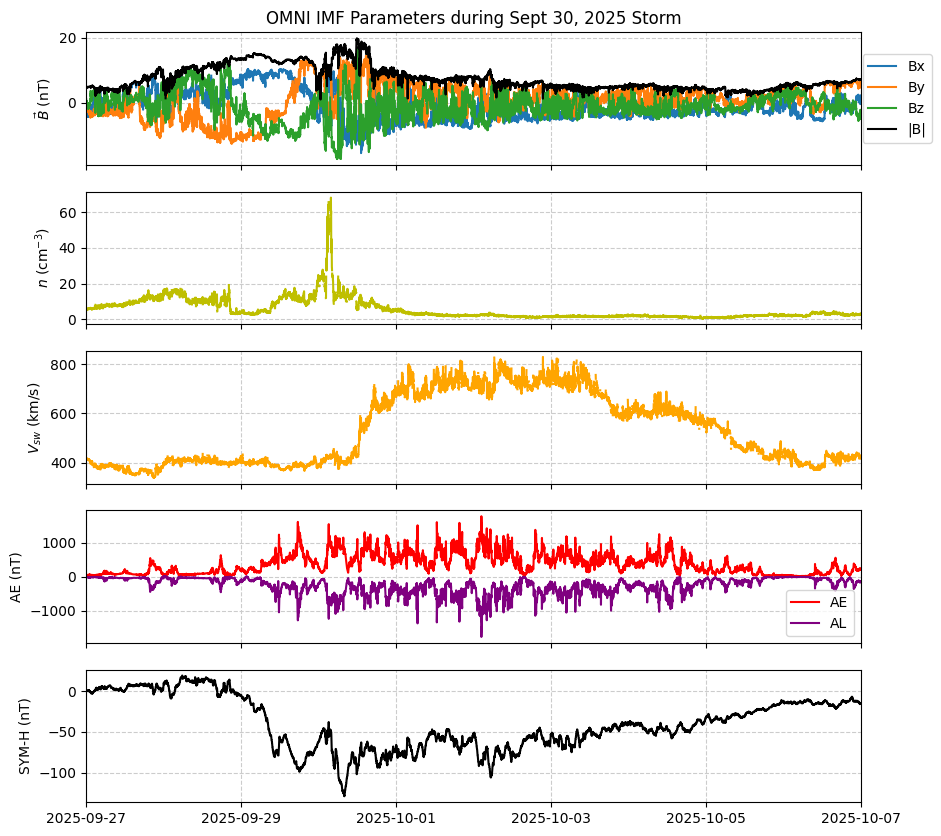

In [14]:

import pylab as plt, numpy as np
from matplotlib import dates as mdates

fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
#plt.subplots_adjust(left=0.1,
#                    bottom=0.1, 
#                    right=0.9, 
#                    top=0.9, 
#                    wspace=0.4, 
#                    hspace=0)


axes[0].plot(omni_epoch, omni_Bx, label='Bx')
axes[0].plot(omni_epoch, omni_By, label='By')
axes[0].plot(omni_epoch, omni_Bz, label='Bz')
axes[0].plot(omni_epoch, np.sqrt(omni_Bx**2 + omni_By**2 + omni_Bz**2), label='|B|', color='k')
axes[0].legend(ncol=1, bbox_to_anchor=(1.1, .5), loc='center right')
axes[0].set_ylabel('$\\vec{B}$ (nT)')
axes[1].plot(omni_epoch, omni_n, color='y')
axes[1].set_ylabel(r'$n$ (cm$^{-3}$)')
axes[2].plot(omni_epoch, omni_v, color='orange')
axes[2].set_ylabel('$V_{sw}$ (km/s)')
axes[3].plot(omni_epoch, omni_ae, color='red', label='AE')
axes[3].plot(omni_epoch, omni_al, color='purple', label='AL')
axes[3].legend()
axes[3].set_ylabel('AE (nT)')
axes[4].plot(omni_epoch, symh, color='k')
axes[4].set_ylabel('SYM-H (nT)')

for ax in axes:
    import dateutil.parser
    ax.grid(linestyle='dashed', color='#ccc')
    ax.set_xlim(data_xarray['Epoch'].min(), dateutil.parser.parse(end_time))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

#axes[0].axvline(dateutil.parser.parse(target_time), color='r')
axes[0].set_title('OMNI IMF Parameters during Sept 30, 2025 Storm')
plt.savefig(out_name, dpi=300)

In [7]:
np.nanmin(omni_Bz)

-17.45

In [9]:
np.nanmax(omni_v)

829.0